# Part 1 — Sorting Algorithm Comparison
**Algorithm Analysis and Simulation Toolkit | Term 2, SY 2025–2026**

---

### How to use this notebook
Run each cell top-to-bottom with **Shift+Enter**.  
No external widgets needed — everything outputs directly in the cell.

| Cell | What it does |
|------|-------------|
| **Cell 1** | All 8 algorithm definitions + complexity reference table |
| **Cell 2** | Step-by-step swap trace on a small custom array |
| **Cell 3** | Full benchmark — n=1000 by default, change `DATASET_SIZE` |
| **Cell 4** | Performance charts (bar, scalability curve, heatmap) |
| **Cell 5** | Automated test suite — verifies all algorithms |

---

### Complexity Reference

| Algorithm | Best | Average | Worst | Space | Stable |
|-----------|------|---------|-------|-------|--------|
| Bubble Sort | O(n) | O(n²) | O(n²) | O(1) | Yes |
| Selection Sort | O(n²) | O(n²) | O(n²) | O(1) | No |
| Insertion Sort | O(n) | O(n²) | O(n²) | O(1) | Yes |
| Merge Sort | O(n log n) | O(n log n) | O(n log n) | O(n) | Yes |
| Quick Sort | O(n log n) | O(n log n) | O(n²) | O(log n) | No |
| Random-Quick Sort | O(n log n) | O(n log n) | O(n²)* | O(log n) | No |
| Counting Sort | O(n+k) | O(n+k) | O(n+k) | O(k) | Yes |
| Radix Sort | O(nk) | O(nk) | O(nk) | O(n+k) | Yes |

*Worst-case extremely rare with random pivot.


In [1]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 1 — ALL 8 SORTING ALGORITHMS
#  Data structure: Python list (dynamic array, O(1) random access)
#  Each function returns: (sorted_list, comparisons, swaps)
#  No external libraries needed — pure Python throughout.
# ═══════════════════════════════════════════════════════════════════════
%matplotlib inline
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "monospace",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
})
COLORS = ["#E63946","#457B9D","#2A9D8F","#E9C46A","#F4A261","#264653","#A8DADC","#9B5DE5"]

random.seed(42)
np.random.seed(42)

def bubble_sort(arr):
    a = arr[:]; n = len(a); comps = swaps = 0
    for i in range(n):
        swapped = False
        for j in range(n - i - 1):
            comps += 1
            if a[j] > a[j + 1]:
                a[j], a[j + 1] = a[j + 1], a[j]; swaps += 1; swapped = True
        if not swapped: break
    return a, comps, swaps

def selection_sort(arr):
    a = arr[:]; n = len(a); comps = swaps = 0
    for i in range(n):
        min_idx = i
        for j in range(i + 1, n):
            comps += 1
            if a[j] < a[min_idx]: min_idx = j
        if min_idx != i:
            a[i], a[min_idx] = a[min_idx], a[i]; swaps += 1
    return a, comps, swaps

def insertion_sort(arr):
    a = arr[:]; comps = swaps = 0
    for i in range(1, len(a)):
        key = a[i]; j = i - 1
        while j >= 0:
            comps += 1
            if a[j] > key:
                a[j + 1] = a[j]; swaps += 1; j -= 1
            else: break
        a[j + 1] = key
    return a, comps, swaps

def merge_sort(arr):
    comps = [0]
    def merge(L, R):
        out = []; i = j = 0
        while i < len(L) and j < len(R):
            comps[0] += 1
            if L[i] <= R[j]: out.append(L[i]); i += 1
            else: out.append(R[j]); j += 1
        out.extend(L[i:]); out.extend(R[j:]); return out
    def sort(a):
        if len(a) <= 1: return a
        m = len(a) // 2
        return merge(sort(a[:m]), sort(a[m:]))
    return sort(arr[:]), comps[0], 0

def quick_sort(arr):
    comps = [0]; swaps = [0]
    def partition(a, lo, hi):
        pivot = a[hi]; i = lo - 1
        for j in range(lo, hi):
            comps[0] += 1
            if a[j] <= pivot:
                i += 1; a[i], a[j] = a[j], a[i]; swaps[0] += 1
        a[i + 1], a[hi] = a[hi], a[i + 1]; swaps[0] += 1
        return i + 1
    def sort(a, lo, hi):
        if lo < hi:
            p = partition(a, lo, hi)
            sort(a, lo, p - 1); sort(a, p + 1, hi)
    a = arr[:]; sort(a, 0, len(a) - 1)
    return a, comps[0], swaps[0]

def random_quick_sort(arr):
    comps = [0]; swaps = [0]
    def partition(a, lo, hi):
        r = random.randint(lo, hi)
        a[r], a[hi] = a[hi], a[r]; swaps[0] += 1
        pivot = a[hi]; i = lo - 1
        for j in range(lo, hi):
            comps[0] += 1
            if a[j] <= pivot:
                i += 1; a[i], a[j] = a[j], a[i]; swaps[0] += 1
        a[i + 1], a[hi] = a[hi], a[i + 1]; swaps[0] += 1
        return i + 1
    def sort(a, lo, hi):
        if lo < hi:
            p = partition(a, lo, hi)
            sort(a, lo, p - 1); sort(a, p + 1, hi)
    a = arr[:]; sort(a, 0, len(a) - 1)
    return a, comps[0], swaps[0]

def counting_sort(arr):
    if not arr: return [], 0, 0
    a = arr[:]; mx = max(a); cnt = [0] * (mx + 1); comps = 0
    for v in a: cnt[v] += 1; comps += 1
    result = [i for i, c in enumerate(cnt) for _ in range(c)]
    return result, comps, 0

def radix_sort(arr):
    if not arr: return [], 0, 0
    a = arr[:]; mx = max(a); comps = 0; exp = 1
    while mx // exp > 0:
        buckets = [[] for _ in range(10)]
        for num in a:
            buckets[(num // exp) % 10].append(num); comps += 1
        a = [x for b in buckets for x in b]
        exp *= 10
    return a, comps, 0

ALGORITHMS = [
    ("Bubble Sort",       bubble_sort),
    ("Selection Sort",    selection_sort),
    ("Insertion Sort",    insertion_sort),
    ("Merge Sort",        merge_sort),
    ("Quick Sort",        quick_sort),
    ("Random-Quick Sort", random_quick_sort),
    ("Counting Sort",     counting_sort),
    ("Radix Sort",        radix_sort),
]

SHORT = ["Bubble","Selection","Insertion","Merge","Quick","Rnd-Quick","Counting","Radix"]
print("====================================================")
print("  Part 1 — Sorting Algorithms  |  8 loaded")
print("====================================================")
for (name, _), col in zip(ALGORITHMS, COLORS):
    print(f"  ●  {name}")
print("\n  Run the next cells to benchmark, trace, and test.")

def make_dataset(n, itype="random"):
    if itype == "random": return [random.randint(0, 9999) for _ in range(n)]
    elif itype == "sorted": return list(range(n))
    elif itype == "reversed": return list(range(n, 0, -1))
    else: raise ValueError(f"Unknown itype: {itype!r}")

import seaborn as sns
PALETTE   = sns.color_palette("deep", 10)
PAL_NAMES = {n: PALETTE[i] for i, n in enumerate(["Bubble Sort","Selection Sort","Insertion Sort","Merge Sort","Quick Sort","Random-Quick Sort","Counting Sort","Radix Sort","Kruskal","Prim"])}
GREEN  = "#10B981"
BLUE   = "#2563EB"
SLATE  = "#64748B"
FIG_BG = "#F8FAFC"

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor":  FIG_BG, "axes.facecolor": "white",
    "axes.edgecolor": "#E2E8F0", "axes.linewidth": 0.8,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.titlepad": 12, "axes.labelsize": 10,
    "axes.labelcolor": "#374151", "axes.labelpad": 6,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.color": "#6B7280", "ytick.color": "#6B7280",
    "grid.color": "#E5E7EB", "grid.linewidth": 0.7, "grid.alpha": 0.8,
    "legend.frameon": True, "legend.framealpha": 0.92,
    "legend.fontsize": 9, "legend.edgecolor": "#E2E8F0",
    "figure.dpi": 130, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.size": 10,
})

def style_ax(ax, remove_spines=("top","right")):
    for sp in remove_spines: ax.spines[sp].set_visible(False)
    ax.tick_params(length=0)

def annotate_bars_h(ax, bars, fmt=".2f", offset_frac=0.015):
    xmax = ax.get_xlim()[1]
    for bar in bars:
        w = bar.get_width()
        label = f"{w:{fmt}}" if 'f' in fmt else f"{int(w):,}"
        ax.text(w + xmax * offset_frac, bar.get_y() + bar.get_height() / 2, label, va="center", ha="left", fontsize=8.5, color="#374151", fontweight="600")


  Part 1 — Sorting Algorithms  |  8 loaded
  ●  Bubble Sort
  ●  Selection Sort
  ●  Insertion Sort
  ●  Merge Sort
  ●  Quick Sort
  ●  Random-Quick Sort
  ●  Counting Sort
  ●  Radix Sort

  Run the next cells to benchmark, trace, and test.


In [2]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 2 — STEP-BY-STEP TRACE
#  Shows every swap Bubble Sort makes on a small array.
# ═══════════════════════════════════════════════════════════════════════
INPUT_ARRAY = [9, 3, 7, 1, 5, 8, 2, 6, 4]   # ← change me!

def trace_bubble(arr):
    a = arr[:]; n = len(a); step = total_comps = total_swaps = 0
    print("─" * 58)
    print(f"  BUBBLE SORT — Swap-by-Swap Trace")
    print("─" * 58)
    print(f"  Input : {a}\n")
    for i in range(n):
        pass_swaps = 0
        for j in range(n - i - 1):
            total_comps += 1
            if a[j] > a[j + 1]:
                a[j], a[j + 1] = a[j + 1], a[j]
                step += 1; pass_swaps += 1; total_swaps += 1
                print(f"  Step {step:>3}  swap[{j}]↔[{j+1}]  →  {a}")
        if pass_swaps == 0:
            print(f"  Pass {i+1:>2}  — zero swaps → EARLY EXIT")
            break
        else:
            print(f"  ── end of pass {i+1} ({pass_swaps} swap{'s' if pass_swaps>1 else ''}) ──")
    print(f"\n  Sorted : {a}\n  Total comparisons : {total_comps}\n  Total swaps       : {total_swaps}\n" + "─" * 58)

trace_bubble(INPUT_ARRAY)

print()
def trace_insertion(arr):
    a = arr[:]; step = 0
    print("─" * 58 + f"\n  INSERTION SORT — Insert-by-Insert Trace\n" + "─" * 58 + f"\n  Input : {a}\n")
    for i in range(1, len(a)):
        key = a[i]; j = i - 1; moved = 0
        while j >= 0 and a[j] > key:
            a[j + 1] = a[j]; j -= 1; moved += 1
        a[j + 1] = key; step += 1
        action = f"insert {key} at [{j+1}]" if moved else f"{key} already in place"
        print(f"  Step {step:>2}  {action:<25}  →  {a}")
    print(f"\n  Sorted : {a}\n" + "─" * 58)

trace_insertion(INPUT_ARRAY)


──────────────────────────────────────────────────────────
  BUBBLE SORT — Swap-by-Swap Trace
──────────────────────────────────────────────────────────
  Input : [9, 3, 7, 1, 5, 8, 2, 6, 4]

  Step   1  swap[0]↔[1]  →  [3, 9, 7, 1, 5, 8, 2, 6, 4]
  Step   2  swap[1]↔[2]  →  [3, 7, 9, 1, 5, 8, 2, 6, 4]
  Step   3  swap[2]↔[3]  →  [3, 7, 1, 9, 5, 8, 2, 6, 4]
  Step   4  swap[3]↔[4]  →  [3, 7, 1, 5, 9, 8, 2, 6, 4]
  Step   5  swap[4]↔[5]  →  [3, 7, 1, 5, 8, 9, 2, 6, 4]
  Step   6  swap[5]↔[6]  →  [3, 7, 1, 5, 8, 2, 9, 6, 4]
  Step   7  swap[6]↔[7]  →  [3, 7, 1, 5, 8, 2, 6, 9, 4]
  Step   8  swap[7]↔[8]  →  [3, 7, 1, 5, 8, 2, 6, 4, 9]
  ── end of pass 1 (8 swaps) ──
  Step   9  swap[1]↔[2]  →  [3, 1, 7, 5, 8, 2, 6, 4, 9]
  Step  10  swap[2]↔[3]  →  [3, 1, 5, 7, 8, 2, 6, 4, 9]
  Step  11  swap[4]↔[5]  →  [3, 1, 5, 7, 2, 8, 6, 4, 9]
  Step  12  swap[5]↔[6]  →  [3, 1, 5, 7, 2, 6, 8, 4, 9]
  Step  13  swap[6]↔[7]  →  [3, 1, 5, 7, 2, 6, 4, 8, 9]
  ── end of pass 2 (5 swaps) ──
  Step  14  swap

In [3]:
# =========================================================
#  CELL 3 - BENCHMARK
#  Change DATASET_SIZE and INPUT_TYPE here.
# =========================================================
DATASET_SIZE = 1000           # try: 100, 500, 1000, 2000, 5000
INPUT_TYPE   = "random"       # "random" | "sorted" | "reversed"

random.seed(0)
dataset  = make_dataset(DATASET_SIZE, INPUT_TYPE)
expected = sorted(dataset)

print("=" * 68)
print(f"  BENCHMARK  |  Dataset Size: {DATASET_SIZE}  |  Input: {INPUT_TYPE}")
print("=" * 68)
print(f"  Input (first 15)  : {dataset[:15]}...\n")

results = []
for name, fn in ALGORITHMS:
    t0 = time.perf_counter()
    sorted_out, comps, swaps = fn(dataset[:])
    elapsed_ms = (time.perf_counter() - t0) * 1000
    results.append((name, elapsed_ms, comps, swaps, sorted_out, sorted_out == expected))

results.sort(key=lambda r: r[1])

W = [22, 11, 15, 12, 6]
header = f"  {'Algorithm':<{W[0]}} {'Time (ms)':>{W[1]}}  {'Comparisons':>{W[2]}} {'Swaps':>{W[3]}} {'OK?':>{W[4]}}"
print(header + "\n  " + "-" * (sum(W) + 8))
for rank, (name, ms, comps, swaps, _, correct) in enumerate(results, 1):
    crown = "  <- FASTEST" if rank == 1 else ""
    print(f"  {name:<{W[0]}} {ms:>{W[1]}.3f}  {comps:>{W[2]},} {swaps:>{W[3]},} {'OK' if correct else 'FAIL':>{W[4]}}{crown}")

fastest = results[0]; slowest = results[-1]
print(f"\n  Fastest : {fastest[0]}  ({fastest[1]:.3f} ms)\n  Slowest : {slowest[0]}  ({slowest[1]:.3f} ms)")
if fastest[1] > 0: print(f"  Ratio   : {slowest[1]/fastest[1]:.1f}x slower")
print(f"\n  Sorted Output (first 20 elements):\n  {results[0][4][:20]}\n" + "=" * 68)


  BENCHMARK  |  Dataset Size: 1000  |  Input: random
  Input (first 15)  : [6311, 6890, 663, 4242, 8376, 7961, 6634, 4969, 7808, 5866, 9558, 3578, 8268, 2281, 4617]...

  Algorithm                Time (ms)      Comparisons        Swaps    OK?
  --------------------------------------------------------------------------
  Radix Sort                   0.216            4,000            0     OK  <- FASTEST
  Counting Sort                0.341            1,000            0     OK
  Quick Sort                   0.594           10,298        5,740     OK
  Random-Quick Sort            0.699           10,032        6,535     OK
  Merge Sort                   0.789            8,721            0     OK
  Insertion Sort               8.646          250,763      249,768     OK
  Selection Sort               9.368          499,500          990     OK
  Bubble Sort                 19.867          499,149      249,768     OK

  Fastest : Radix Sort  (0.216 ms)
  Slowest : Bubble Sort  (19.867 ms)
  R

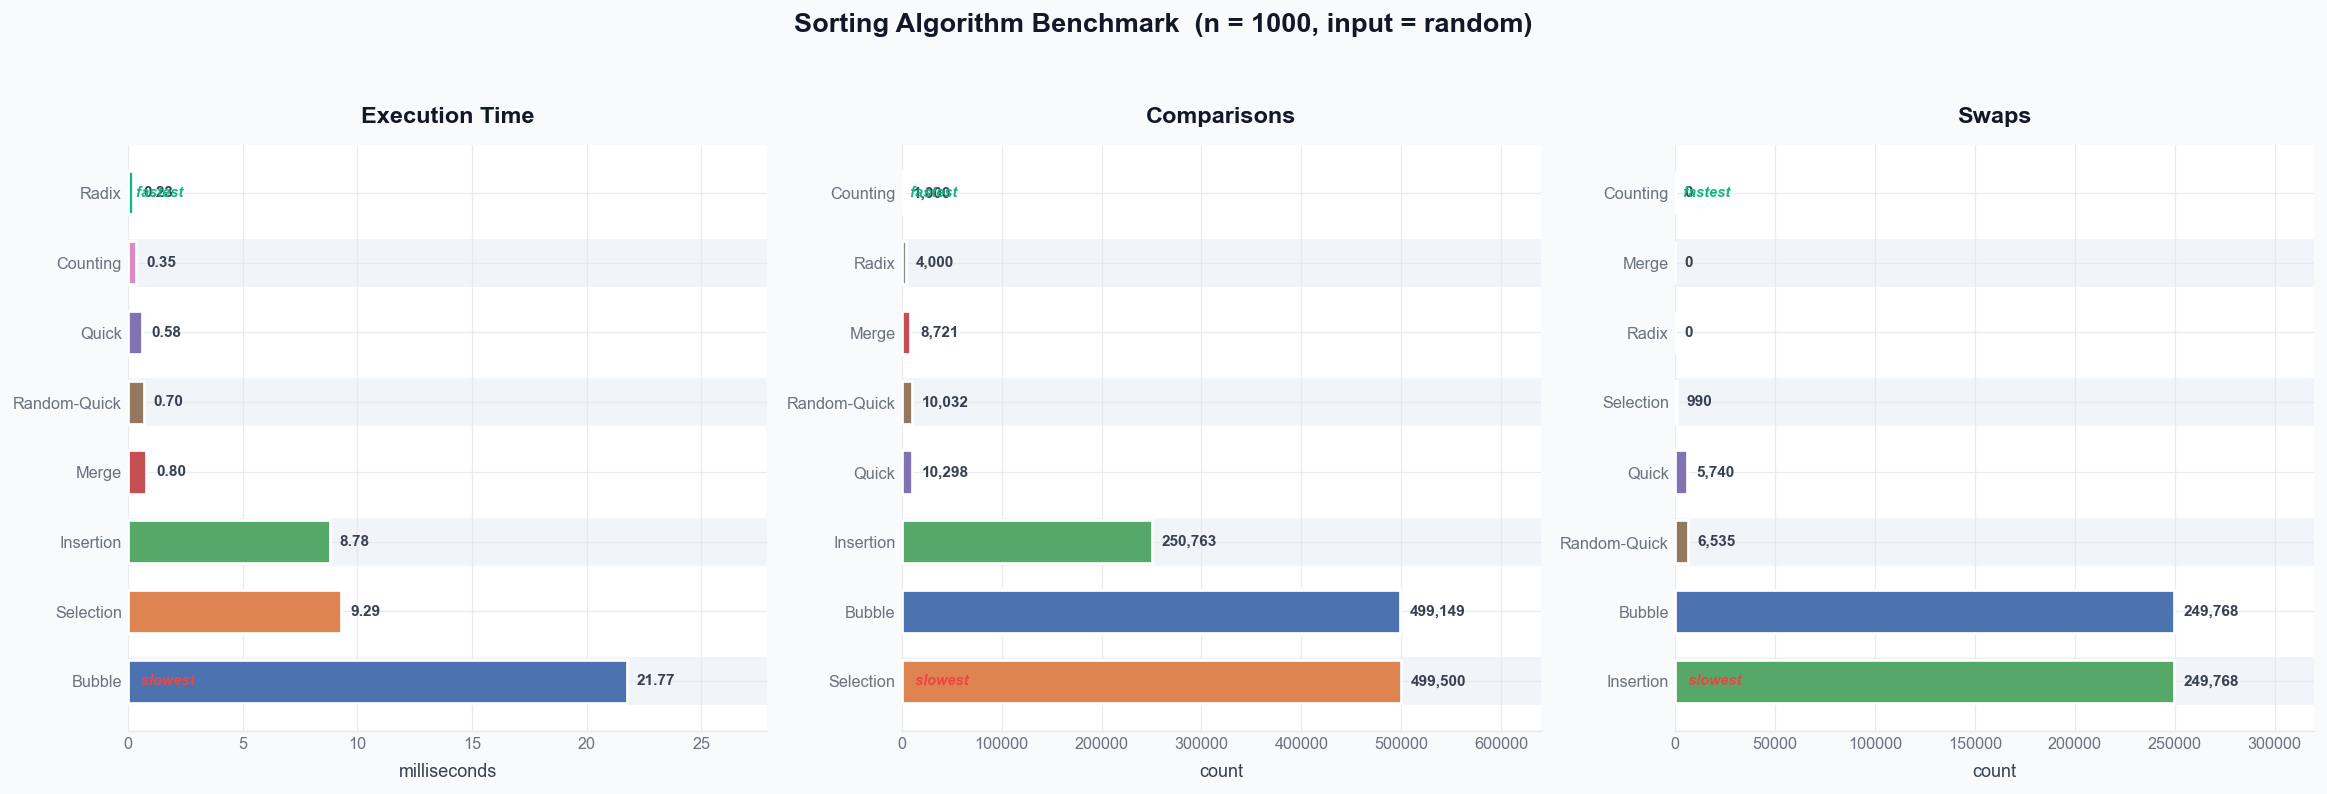

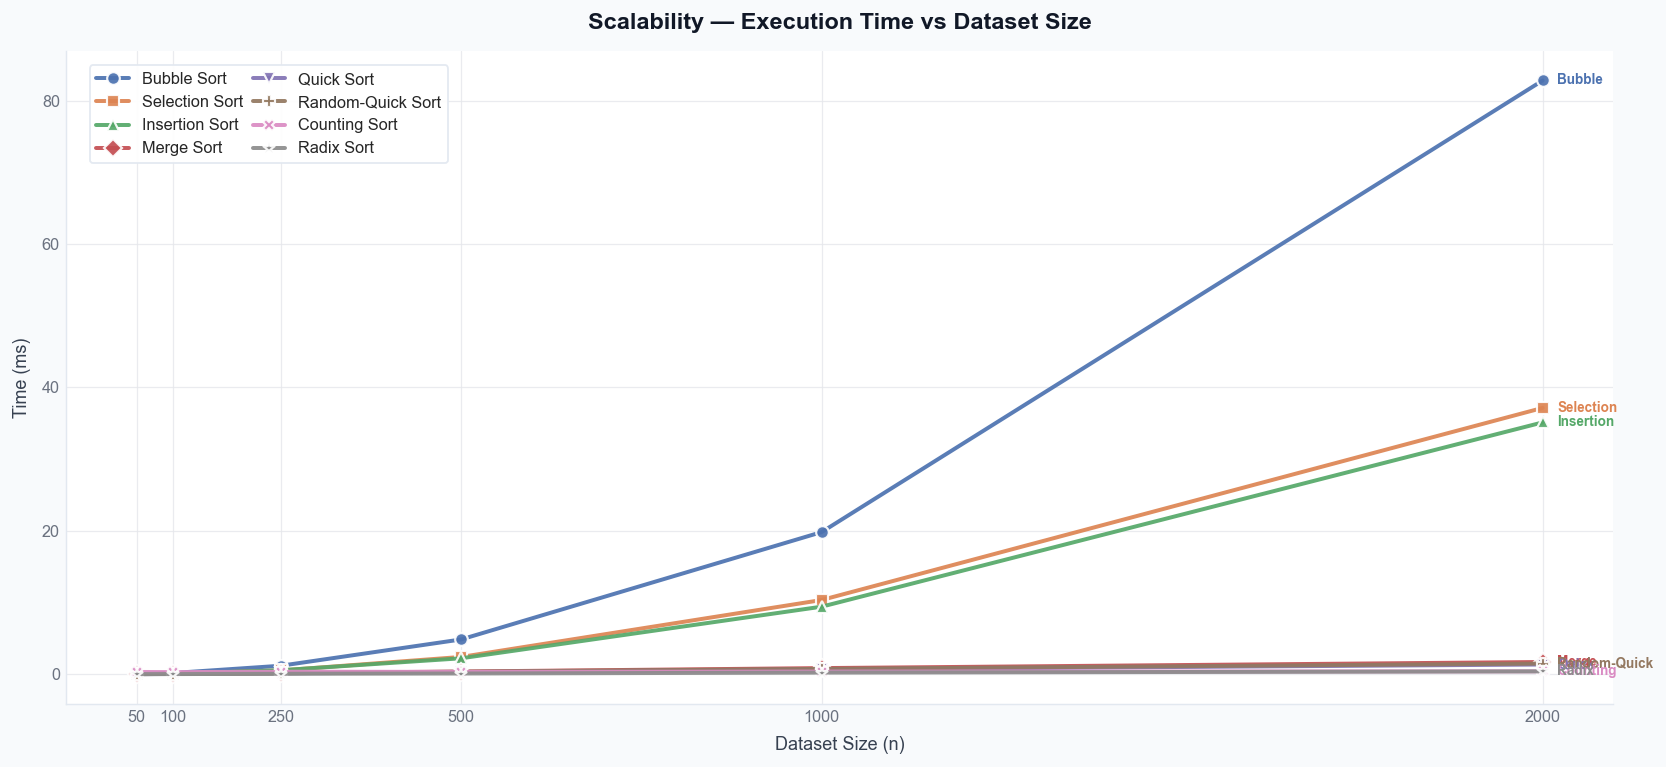

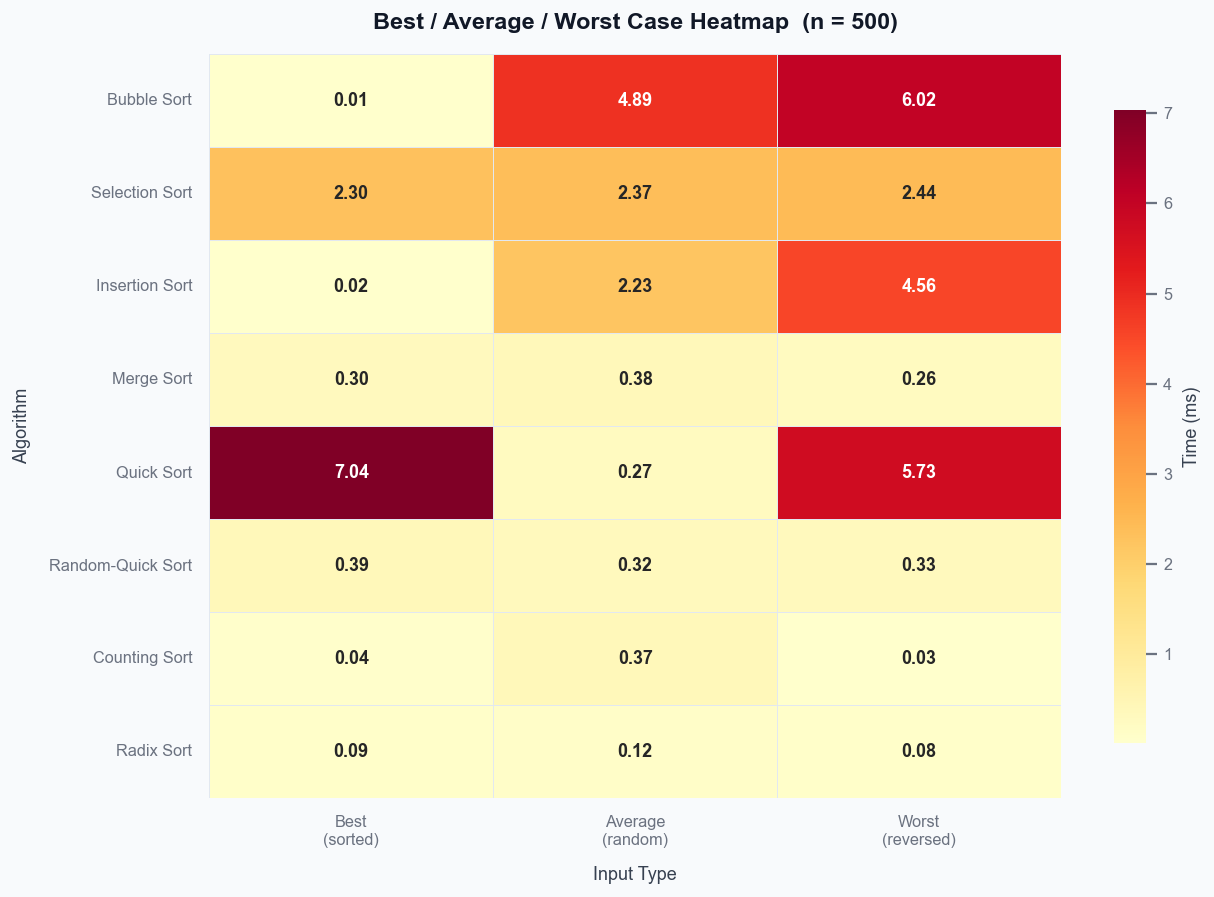

In [4]:
# =========================================================
#  CELL 4 — PERFORMANCE CHARTS (Displays inline)
# =========================================================
random.seed(0)
_bdata  = make_dataset(DATASET_SIZE, "random")
_bnames, _btimes, _bcomps, _bswaps = [], [], [], []
for name, fn in ALGORITHMS:
    t0 = time.perf_counter()
    _, c, s = fn(_bdata[:])
    _bnames.append(name)
    _btimes.append((time.perf_counter() - t0) * 1000)
    _bcomps.append(c)
    _bswaps.append(s)
_bshort = [n.replace(" Sort","") for n in _bnames]

# ── Chart A: Horizontal bar comparison ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(FIG_BG)
fig.suptitle(f"Sorting Algorithm Benchmark  (n = {DATASET_SIZE}, input = {INPUT_TYPE})", fontsize=15, fontweight="bold", color="#111827", y=1.01)

for ax, vals, title, unit in zip(axes, [_btimes, _bcomps, _bswaps], ["Execution Time", "Comparisons", "Swaps"], ["milliseconds", "count", "count"]):
    pairs = sorted(zip(vals, _bshort), reverse=True)
    v_s, l_s = zip(*pairs)
    colors = list([PAL_NAMES.get(f"{l} Sort", PALETTE[i % 8]) for i, l in enumerate(l_s)])
    colors[-1] = GREEN
    bars = ax.barh(l_s, v_s, color=colors, height=0.62, edgecolor="white", linewidth=1.5)
    ax.set_xlim(0, max(v_s) * 1.28); ax.set_title(title, color="#111827"); ax.set_xlabel(unit)
    style_ax(ax, remove_spines=("top","right","left")); ax.tick_params(left=False)
    annotate_bars_h(ax, bars, fmt=".2f" if title == "Execution Time" else ",d")
    for i, patch in enumerate(bars):
        if i % 2 == 0: ax.axhspan(patch.get_y() - 0.02, patch.get_y() + patch.get_height() + 0.02, color="#F1F5F9", zorder=0)
    ax.text(v_s[-1] * 0.01, len(v_s) - 1, "  fastest", va="center", color=GREEN, fontsize=8, fontweight="bold", style="italic")
    ax.text(v_s[0] * 0.01, 0, "  slowest", va="center", color="#EF4444", fontsize=8, fontweight="bold", style="italic")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ── Chart B: Scalability line chart ────────────────────────────────────
SIZES = [50, 100, 250, 500, 1000, 2000]
scale = {name: [] for name, _ in ALGORITHMS}
for sz in SIZES:
    d = [random.randint(0, 9999) for _ in range(sz)]
    for name, fn in ALGORITHMS:
        t0 = time.perf_counter(); fn(d[:]); scale[name].append((time.perf_counter() - t0) * 1000)

fig2, ax2 = plt.subplots(figsize=(13, 6))
fig2.patch.set_facecolor(FIG_BG)
MARKERS = ["o","s","^","D","v","P","X","*"]
for i, (name, _) in enumerate(ALGORITHMS):
    col = PAL_NAMES.get(name, PALETTE[i]); y_vals = scale[name]
    ax2.plot(SIZES, y_vals, marker=MARKERS[i], label=name, color=col, linewidth=2.2, markersize=7, alpha=0.92, markeredgecolor="white", markeredgewidth=1.2)
    ax2.annotate(name.replace(" Sort",""), xy=(SIZES[-1], y_vals[-1]), xytext=(8, 0), textcoords="offset points", va="center", fontsize=7.5, color=col, fontweight="600")
ax2.set_title("Scalability — Execution Time vs Dataset Size", color="#111827")
ax2.set_xlabel("Dataset Size (n)"); ax2.set_ylabel("Time (ms)"); ax2.set_xticks(SIZES)
style_ax(ax2); ax2.legend(loc="upper left", ncol=2, columnspacing=0.6, bbox_to_anchor=(0.01, 0.99))
plt.tight_layout()
plt.show()

# ── Chart C: Seaborn heatmap — best / avg / worst ──────────────────────
n_h = 500
cases_h = {"Best\n(sorted)": list(range(n_h)), "Average\n(random)": [random.randint(0, 9999) for _ in range(n_h)], "Worst\n(reversed)": list(range(n_h, 0, -1))}
matrix_h = np.array([[(lambda t0, fn=fn, d=d: (time.perf_counter() - t0) * 1000)(time.perf_counter(), fn(d[:])) for d in cases_h.values()] for _, fn in ALGORITHMS])

fig3, ax3 = plt.subplots(figsize=(10, 7))
fig3.patch.set_facecolor(FIG_BG)
sns.heatmap(matrix_h, ax=ax3, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5, linecolor="#E2E8F0", cbar_kws={"label": "Time (ms)", "shrink": 0.85}, xticklabels=list(cases_h.keys()), yticklabels=[n for n, _ in ALGORITHMS], annot_kws={"size": 10, "weight": "bold"})
ax3.set_title(f"Best / Average / Worst Case Heatmap  (n = {n_h})", color="#111827", pad=14)
ax3.set_xlabel("Input Type", labelpad=10); ax3.set_ylabel("Algorithm", labelpad=10)
ax3.tick_params(axis="x", rotation=0); ax3.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()


In [5]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 5 — AUTOMATED TEST SUITE
# ═══════════════════════════════════════════════════════════════════════
TEST_CASES = [
    ("Empty array",          []),
    ("Single element",       [42]),
    ("Two — ordered",        [1, 2]),
    ("Two — reversed",       [9, 1]),
    ("All duplicates",       [5, 5, 5, 5, 5]),
    ("Already sorted",       list(range(10))),
    ("Reverse sorted",       list(range(9, -1, -1))),
    ("With duplicates",      [3,1,4,1,5,9,2,6,5,3,5]),
    ("Random n=50",          [random.randint(0,999) for _ in range(50)]),
    ("Random n=200",         [random.randint(0,9999) for _ in range(200)]),
    ("Random n=1000",        [random.randint(0,9999) for _ in range(1000)]),
]
print("=" * 65 + "\n  AUTOMATED TEST SUITE  —  All 8 Algorithms\n" + "=" * 65)
total = passed = 0
all_pass = True
for algo_name, fn in ALGORITHMS:
    fails = []
    for tc_name, tc_data in TEST_CASES:
        total += 1
        try:
            result, _, _ = fn(tc_data[:])
            if result == sorted(tc_data): passed += 1
            else: fails.append(tc_name); all_pass = False
        except Exception as e:
            fails.append(f"{tc_name} [ERR:{e}]"); all_pass = False
    print(f"  {algo_name:<22}  {len(TEST_CASES) - len(fails)}/{len(TEST_CASES)}  {'✓  ALL PASS' if not fails else f'✗  FAILED: {fails}'}")
print("─" * 65 + f"\n  Total: {passed}/{total} tests passed")
if all_pass: print("  🎉 All algorithms verified correct!")
print("=" * 65)


  AUTOMATED TEST SUITE  —  All 8 Algorithms
  Bubble Sort             11/11  ✓  ALL PASS
  Selection Sort          11/11  ✓  ALL PASS
  Insertion Sort          11/11  ✓  ALL PASS
  Merge Sort              11/11  ✓  ALL PASS
  Quick Sort              11/11  ✓  ALL PASS
  Random-Quick Sort       11/11  ✓  ALL PASS
  Counting Sort           11/11  ✓  ALL PASS
  Radix Sort              11/11  ✓  ALL PASS
─────────────────────────────────────────────────────────────────
  Total: 88/88 tests passed
  🎉 All algorithms verified correct!
